In [1]:
# Load Data
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load meteorological data
dataframes_dir = Path('../data/dataframes')
met_pkl_files = list(dataframes_dir.glob("met_*.pkl"))
loaded_met_dfs = []

for pkl_file in sorted(met_pkl_files):
    df = pd.read_pickle(pkl_file)
    loaded_met_dfs.append(df)

met_combined = pd.concat(loaded_met_dfs, ignore_index=True)

# Load wave spectrum data
y_spectra_dir = Path('../data/Y_spectra')
spectrum_pkl_files = list(y_spectra_dir.glob("Y_*.pkl"))
loaded_spectrum_dfs = []

for pkl_file in sorted(spectrum_pkl_files):
    df = pd.read_pickle(pkl_file)
    loaded_spectrum_dfs.append(df)

spectrum_combined = pd.concat(loaded_spectrum_dfs, ignore_index=True)

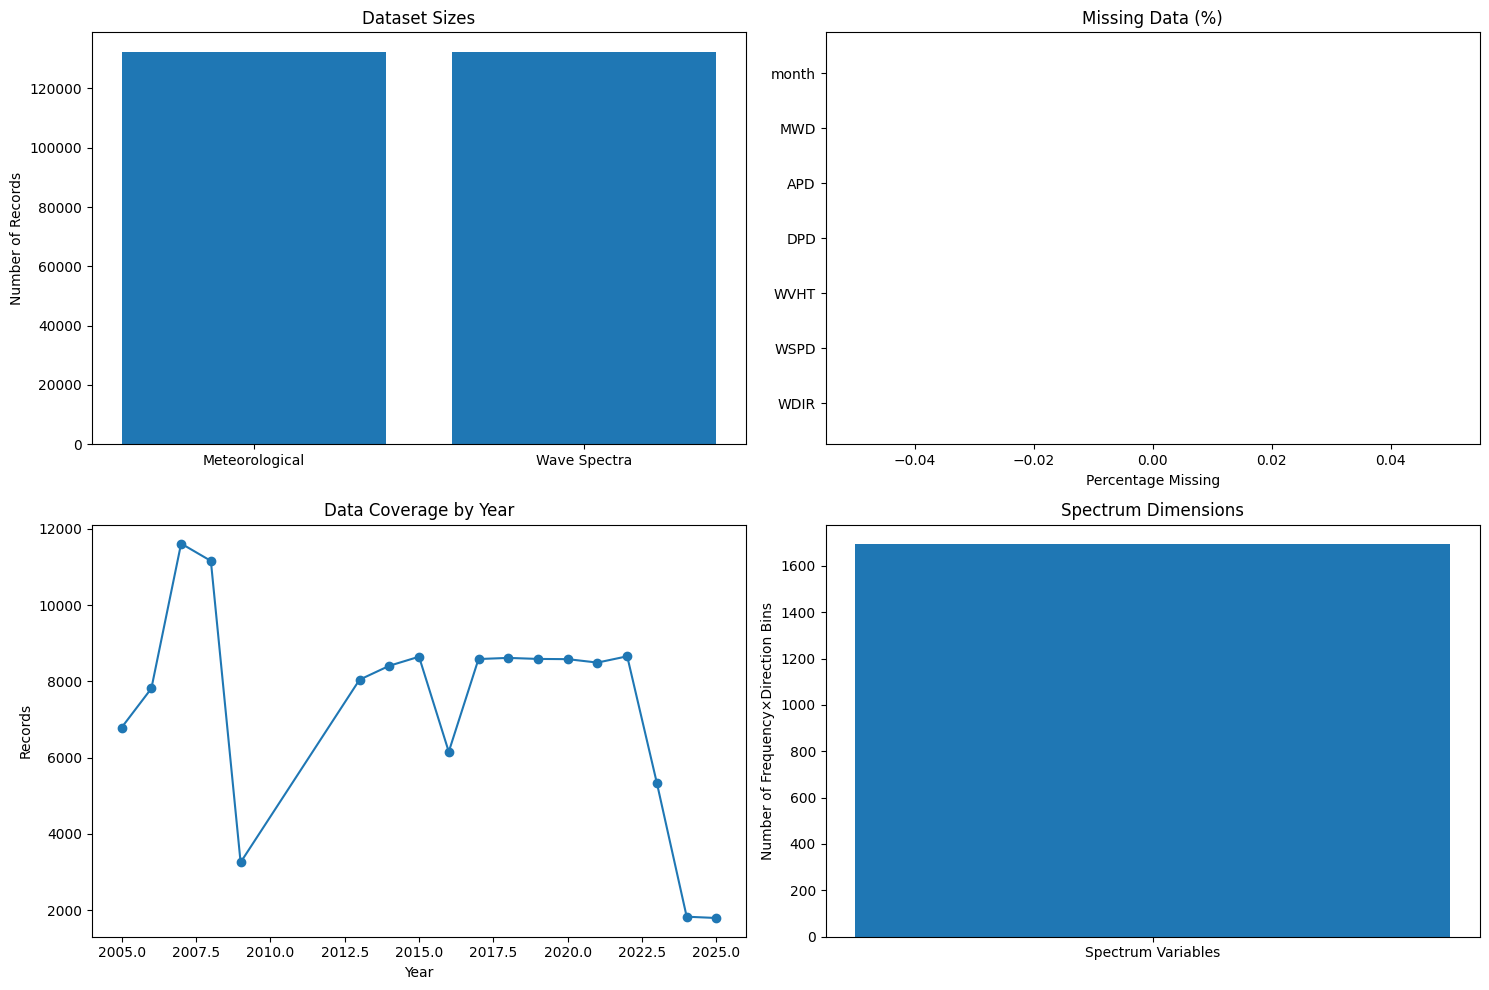

In [12]:
# Basic Data Overview
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Data shapes and time coverage
axes[0, 0].bar(['Meteorological', 'Wave Spectra'], [len(met_combined), len(spectrum_combined)])
axes[0, 0].set_title('Dataset Sizes')
axes[0, 0].set_ylabel('Number of Records')

# Missing data heatmap for meteorological variables
met_numeric = met_combined.select_dtypes(include=[np.number])
missing_data = met_numeric.isnull().sum() / len(met_numeric) * 100
axes[0, 1].barh(missing_data.index, missing_data.values)
axes[0, 1].set_title('Missing Data (%)')
axes[0, 1].set_xlabel('Percentage Missing')

# Data distribution by year (if timekey available)
if 'timekey' in met_combined.columns:
    met_combined['year'] = pd.to_datetime(met_combined['timekey'], format='%Y%m%d%H').dt.year
    year_counts = met_combined['year'].value_counts().sort_index()
    axes[1, 0].plot(year_counts.index, year_counts.values, marker='o')
    axes[1, 0].set_title('Data Coverage by Year')
    axes[1, 0].set_xlabel('Year')
    axes[1, 0].set_ylabel('Records')

# Spectrum data shape info
spectrum_cols = spectrum_combined.select_dtypes(include=[np.number]).shape[1]
axes[1, 1].bar(['Spectrum Variables'], [spectrum_cols])
axes[1, 1].set_title('Spectrum Dimensions')
axes[1, 1].set_ylabel('Number of Frequency×Direction Bins')

plt.tight_layout()
plt.show()

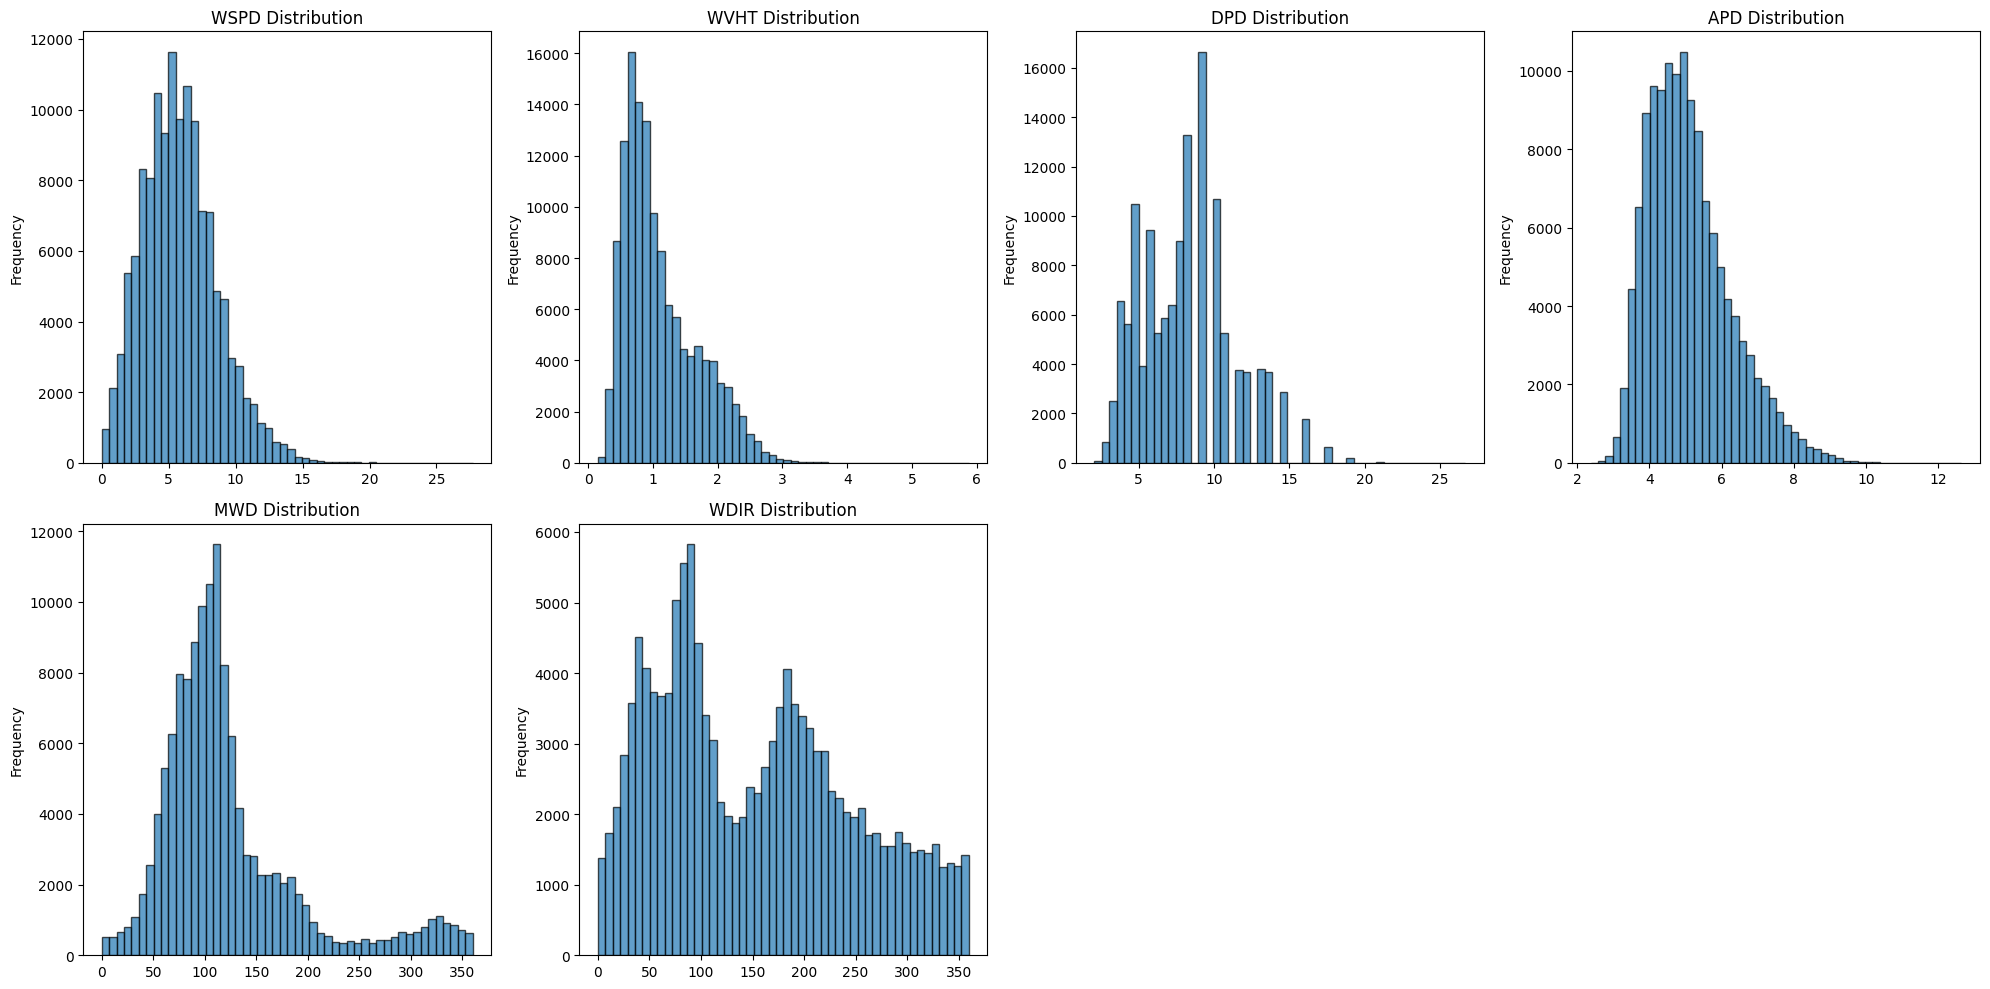

In [3]:
# Meteorological Variables Distribution
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

# Key meteorological variables
met_vars = ['WSPD', 'WVHT', 'DPD', 'APD', 'MWD', 'WDIR']
available_vars = [var for var in met_vars if var in met_combined.columns]

for i, var in enumerate(available_vars[:6]):
    if i < len(axes):
        data = met_combined[var].dropna()
        axes[i].hist(data, bins=50, alpha=0.7, edgecolor='black')
        axes[i].set_title(f'{var} Distribution')
        axes[i].set_ylabel('Frequency')

# Turn off unused subplots
for j in range(len(available_vars), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

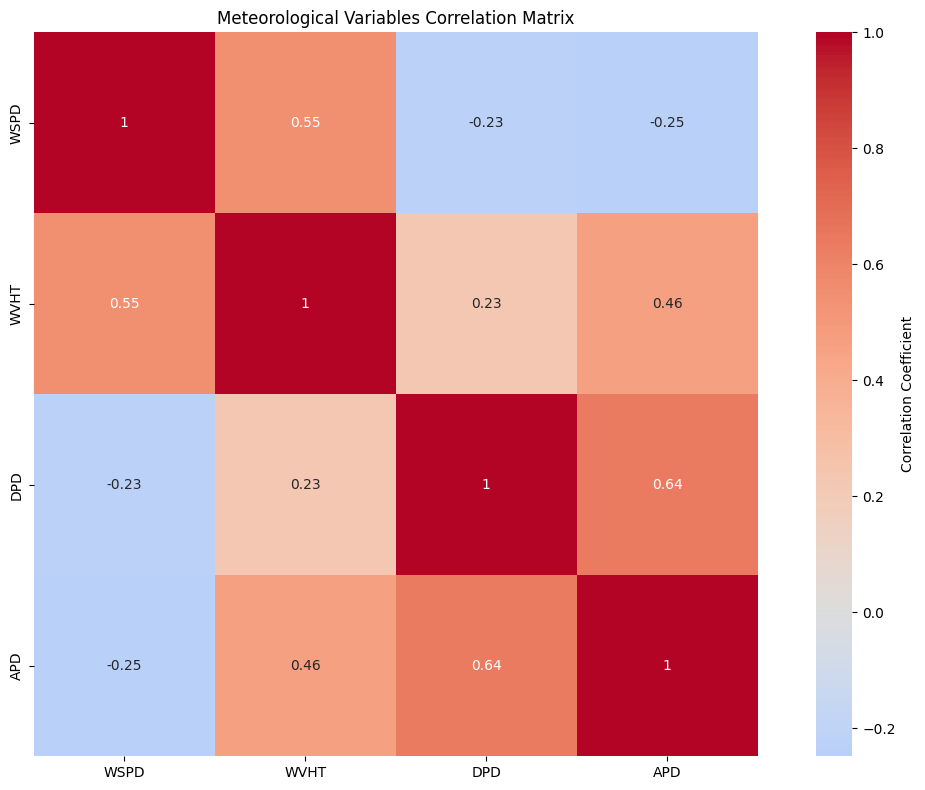

In [4]:
# Correlation Matrix
plt.figure(figsize=(12, 8))

# Select key meteorological variables for correlation
corr_vars = [var for var in ['WSPD', 'WVHT', 'DPD', 'APD'] if var in met_combined.columns]
corr_data = met_combined[corr_vars].corr()

sns.heatmap(corr_data, annot=True, cmap='coolwarm', center=0, 
            square=True, cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Meteorological Variables Correlation Matrix')
plt.tight_layout()
plt.show()

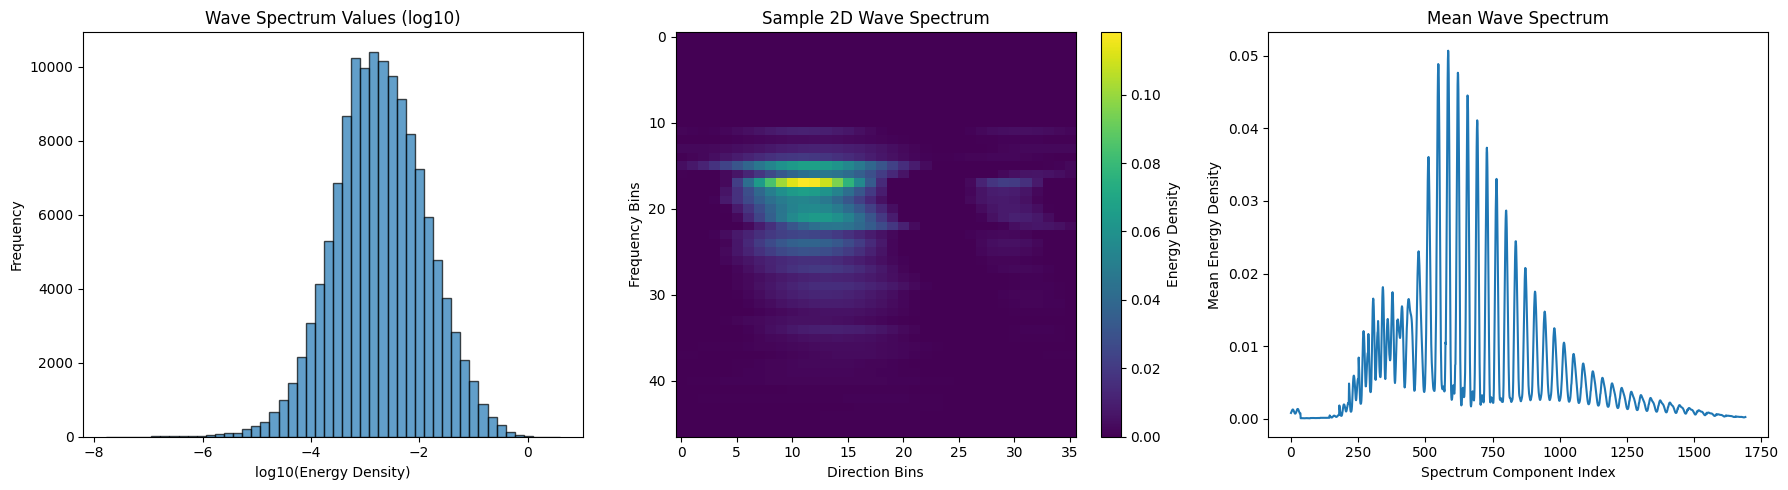

In [5]:
# Wave Spectrum Analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Get spectrum values (exclude datetime and metadata columns)
spectrum_numeric = spectrum_combined.select_dtypes(include=[np.number])

# Distribution of spectrum values
spectrum_values = spectrum_numeric.values.flatten()
spectrum_values = spectrum_values[spectrum_values > 0]  # Remove zeros

axes[0].hist(np.log10(spectrum_values[::1000]), bins=50, alpha=0.7, edgecolor='black')
axes[0].set_title('Wave Spectrum Values (log10)')
axes[0].set_xlabel('log10(Energy Density)')
axes[0].set_ylabel('Frequency')

# Sample spectrum visualization (first record)
sample_spectrum = spectrum_numeric.iloc[0].values
# Assuming roughly square grid (47x36 = 1692)
if len(sample_spectrum) == 1692:
    spectrum_2d = sample_spectrum.reshape(47, 36)
    im = axes[1].imshow(spectrum_2d, aspect='auto', cmap='viridis')
    axes[1].set_title('Sample 2D Wave Spectrum')
    axes[1].set_xlabel('Direction Bins')
    axes[1].set_ylabel('Frequency Bins')
    plt.colorbar(im, ax=axes[1], label='Energy Density')

# Mean spectrum across all records
mean_spectrum = spectrum_numeric.mean().values
axes[2].plot(mean_spectrum)
axes[2].set_title('Mean Wave Spectrum')
axes[2].set_xlabel('Spectrum Component Index')
axes[2].set_ylabel('Mean Energy Density')

plt.tight_layout()
plt.show()

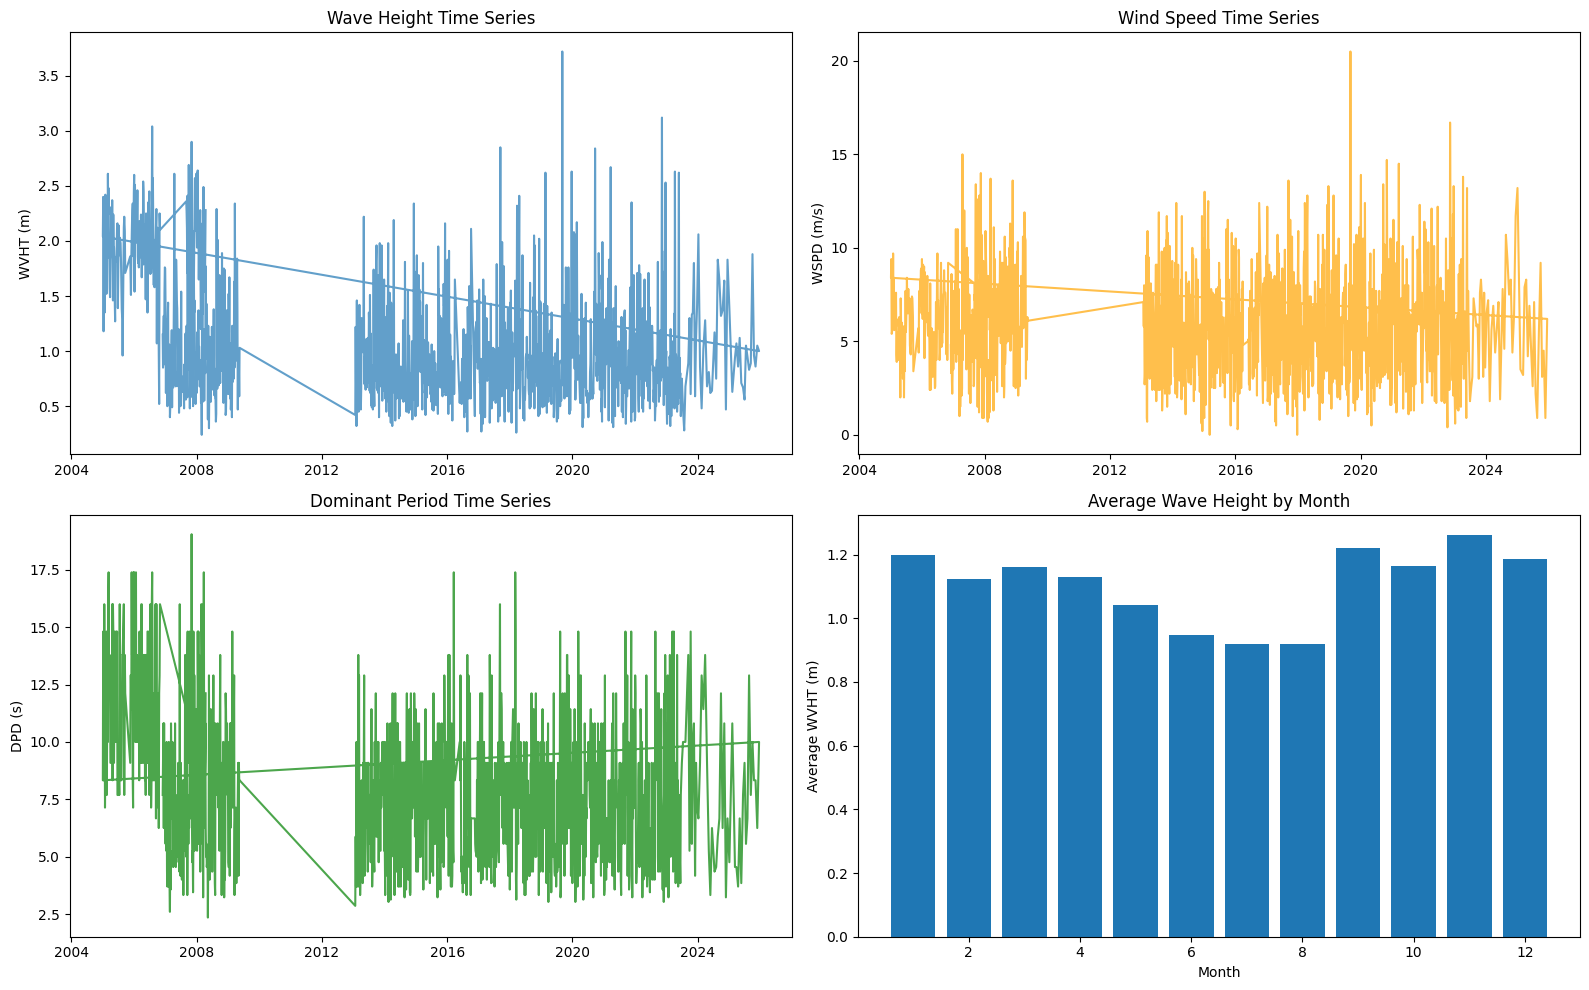

In [11]:
# Time Series Analysis (using timekey)
if 'timekey' in met_combined.columns:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    # Convert timekey to datetime (format: YYYYMMDDHH)
    met_combined['datetime'] = pd.to_datetime(met_combined['timekey'], format='%Y%m%d%H')
    
    # Sample time series for key variables (subsample for performance)
    sample_data = met_combined.iloc[::100].copy()  # Every 100th record
    
    if 'WVHT' in sample_data.columns:
        axes[0, 0].plot(sample_data['datetime'], sample_data['WVHT'], alpha=0.7)
        axes[0, 0].set_title('Wave Height Time Series')
        axes[0, 0].set_ylabel('WVHT (m)')
    
    if 'WSPD' in sample_data.columns:
        axes[0, 1].plot(sample_data['datetime'], sample_data['WSPD'], alpha=0.7, color='orange')
        axes[0, 1].set_title('Wind Speed Time Series')
        axes[0, 1].set_ylabel('WSPD (m/s)')
    
    if 'DPD' in sample_data.columns:
        axes[1, 0].plot(sample_data['datetime'], sample_data['DPD'], alpha=0.7, color='green')
        axes[1, 0].set_title('Dominant Period Time Series')
        axes[1, 0].set_ylabel('DPD (s)')
    
    # Seasonal patterns (monthly averages)
    if 'WVHT' in met_combined.columns:
        met_combined['month'] = met_combined['datetime'].dt.month
        monthly_avg = met_combined.groupby('month')['WVHT'].mean()
        axes[1, 1].bar(monthly_avg.index, monthly_avg.values)
        axes[1, 1].set_title('Average Wave Height by Month')
        axes[1, 1].set_xlabel('Month')
        axes[1, 1].set_ylabel('Average WVHT (m)')
    
    plt.tight_layout()
    plt.show()